In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q efficientnet-pytorch grad-cam pytorch-ignite

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report)
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [18]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:",device)

Using: cuda


In [33]:
class Config:
    DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
    import glob
    all_image_dirs = glob.glob(os.path.join(DATA_DIR, "images_*/images"))
    
    all_images = []
    for img_dir in all_image_dirs:
        all_images.extend(glob.glob(os.path.join(img_dir, "*.png")))
    
    if all_images:
        IMG_DIR = os.path.dirname(all_images[0])
        print(f"Found {len(all_images)} images in {len(all_image_dirs)} directories")
        print(f"Using images from: {IMG_DIR}")
    else:
        IMG_DIR = None
    CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
    TRAIN_LIST = os.path.join(DATA_DIR, 'train_val_list.txt')
    TEST_LIST = os.path.join(DATA_DIR, 'test_list.txt')
    BBOX_PATH = os.path.join(DATA_DIR, 'BBox_List_2017.csv')
    
    IMG_SIZE = 256
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 1e-3
    NUM_CLASSES = 14

    NUM_WORKERS = 4
    PIN_MEMORY = True
    GRADIENT_ACCUMULATION_STEPS = 1
    
    # Disease names in order
    DISEASES = [
        'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 
        'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 
        'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 
        'Pleural_Thickening', 'Hernia'
    ]
    
    PATIENCE = 3
    
config = Config()

Found 112120 images in 12 directories
Using images from: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images


In [34]:
df = pd.read_csv(config.CSV_PATH)
print(f"Total images: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

def analyze_labels(df, diseases):
    label_lists = df['Finding Labels'].str.split('|')
    all_labels = [label for sublist in label_lists for label in sublist]
    
    print("="*50)
    print("LABEL DISTRIBUTION")
    print("="*50)
    
    distributions = {}
    for disease in diseases:
        count = (df['Finding Labels'].str.contains(disease, na=False)).sum()
        distributions[disease] = count
        print(f"{disease:20s}: {count:6d} ({count/len(df)*100:.2f}%)")
    
    num_labels_per_image = [len(labels) for labels in label_lists]
    print(f"\n{'='*50}")
    print("MULTI-LABEL STATISTICS")
    print(f"Average diseases per image: {np.mean(num_labels_per_image):.2f}")
    print(f"Max diseases in one image: {max(num_labels_per_image)}")
    print(f"Images with no finding: {(df['Finding Labels'] == 'No Finding').sum()}")
    
    return distributions

distributions = analyze_labels(df, config.DISEASES)

Total images: 112120
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

First few rows:
LABEL DISTRIBUTION
Atelectasis         :  11559 (10.31%)
Cardiomegaly        :   2776 (2.48%)
Effusion            :  13317 (11.88%)
Infiltration        :  19894 (17.74%)
Mass                :   5782 (5.16%)
Nodule              :   6331 (5.65%)
Pneumonia           :   1431 (1.28%)
Pneumothorax        :   5302 (4.73%)
Consolidation       :   4667 (4.16%)
Edema               :   2303 (2.05%)
Emphysema           :   2516 (2.24%)
Fibrosis            :   1686 (1.50%)
Pleural_Thickening  :   3385 (3.02%)
Hernia              :    227 (0.20%)

MULTI-LABEL STATISTICS
Average diseases per image: 1.26
Max diseases in one image: 9
Images with no finding: 60361


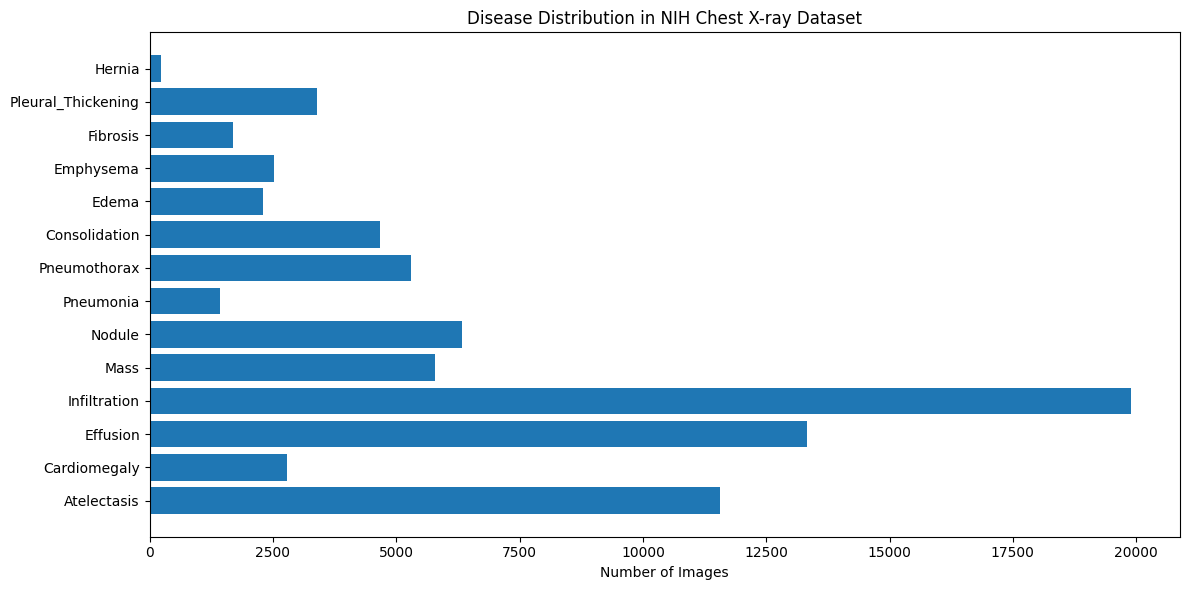

In [35]:
plt.figure(figsize=(12, 6))
disease_counts = [distributions[d] for d in config.DISEASES]
plt.barh(config.DISEASES, disease_counts)
plt.xlabel('Number of Images')
plt.title('Disease Distribution in NIH Chest X-ray Dataset')
plt.tight_layout()
plt.show()

In [36]:
class ChestXrayDataset(Dataset):
    def __init__(self, data_dir, csv_path, split_file, diseases, transform=None, is_train=True):
        self.data_dir = data_dir
        self.diseases = diseases
        self.transform = transform
        self.is_train = is_train
  
        import glob
        self.image_dirs = sorted(glob.glob(os.path.join(data_dir, "images_*/images")))
        print(f"Found {len(self.image_dirs)} image directories: {[os.path.basename(d) for d in self.image_dirs]}")
        
        self.df = pd.read_csv(csv_path)
        
        if os.path.exists(split_file):
            with open(split_file, 'r') as f:
                split_images = [line.strip() for line in f.readlines()]
            self.df = self.df[self.df['Image Index'].isin(split_images)].reset_index(drop=True)
        
        if is_train:
            self.df = self.df[self.df['Finding Labels'] != 'No Finding']
        
        print(f"{'Train' if is_train else 'Val/Test'} set: {len(self.df)} images")
    
    def __len__(self):
        return len(self.df)
    
    def _get_multilabel(self, labels_str):
        labels = [1 if disease in labels_str else 0 for disease in self.diseases]
        return torch.FloatTensor(labels)
    
    def _find_image_path(self, img_name):
        for img_dir in self.image_dirs:
            img_path = os.path.join(img_dir, img_name)
            if os.path.exists(img_path):
                return img_path
        return None
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Index']
        img_path = self._find_image_path(img_name)
        
        if img_path is None:
            print(f"ERROR: Image not found: {img_name}")
            print(f"Searched in: {self.image_dirs}")
            raise FileNotFoundError(f"Image {img_name} not found in any directory")
        
        image = Image.open(img_path).convert('RGB')
        
        labels_str = self.df.iloc[idx]['Finding Labels']
        labels = self._get_multilabel(labels_str)
        
        if self.transform:
            image = self.transform(image)
        
        metadata = {
            'img_name': img_name,
            'patient_id': self.df.iloc[idx]['Patient ID'] if 'Patient ID' in self.df.columns else 'Unknown',
            'age': self.df.iloc[idx]['Patient Age'] if 'Patient Age' in self.df.columns else 0,
            'gender': self.df.iloc[idx]['Patient Gender'] if 'Patient Gender' in self.df.columns else 'Unknown'
        }
        
        return image, labels, metadata

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [38]:
train_dataset = ChestXrayDataset(
    config.DATA_DIR,
    config.CSV_PATH, 
    config.TRAIN_LIST,
    config.DISEASES, 
    transform=train_transform, 
    is_train=True
)

val_dataset = ChestXrayDataset(
    config.DATA_DIR,
    config.CSV_PATH, 
    config.TEST_LIST,
    config.DISEASES, 
    transform=val_transform, 
    is_train=False
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, 
    shuffle=True, num_workers=4, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

Found 12 image directories: ['images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images']
Train set: 36024 images
Found 12 image directories: ['images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images']
Val/Test set: 25596 images


In [39]:
import torchvision.models as models
import torch.nn as nn

class EfficientNetMultiLabel(nn.Module):
    def __init__(self, model_name='efficientnet_b1', num_classes=14, pretrained=True):
        super().__init__()

        if pretrained:
            self.backbone = models.efficientnet_b1(weights='DEFAULT')
        else:
            self.backbone = models.efficientnet_b1(weights=None)

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [40]:
def compute_class_weights(train_dataset, diseases):
    df = train_dataset.df
    
    label_matrix = np.zeros((len(df), len(diseases)))
    
    for i, disease in enumerate(diseases):
        label_matrix[:, i] = df['Finding Labels'].str.contains(disease, na=False).astype(int)
    
    pos_counts = label_matrix.sum(axis=0)
    neg_counts = len(df) - pos_counts
    
    pos_weight = neg_counts / (pos_counts + 1e-6)
    pos_weight = torch.FloatTensor(pos_weight).to(device)
    
    print("\nClass Weights (pos_weight):")
    for disease, weight in zip(diseases, pos_weight.cpu()):
        print(f"{disease:20s}: {weight:.4f}")
    
    return pos_weight

In [41]:
model = EfficientNetMultiLabel(model_name='efficientnet_b1',num_classes=config.NUM_CLASSES,pretrained=True)
model = model.to(device)

pos_weight = compute_class_weights(train_dataset, config.DISEASES).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler()

print(f"\nModel total parameters: {sum(p.numel() for p in model.parameters()):,}")


Class Weights (pos_weight):
Atelectasis         : 3.3507
Cardiomegaly        : 20.1037
Effusion            : 3.1603
Infiltration        : 1.6138
Mass                : 7.9301
Nodule              : 6.6517
Pneumonia           : 40.1233
Pneumothorax        : 12.6610
Consolidation       : 11.6311
Edema               : 25.1422
Emphysema           : 24.3155
Fibrosis            : 27.7962
Pleural_Thickening  : 15.0678
Hernia              : 254.4894

Model total parameters: 6,531,118


In [42]:
class MetricsTracker:
    def __init__(self, diseases):
        self.diseases = diseases
        self.reset()
    
    def reset(self):
        self.all_labels = []
        self.all_preds = []
        self.all_logits = []
        self.losses = []
    
    def update(self, logits, labels, loss):
        self.all_logits.extend(logits.cpu().detach().numpy())
        self.all_labels.extend(labels.cpu().numpy())
        self.losses.append(loss)
    
    def compute_metrics(self):
        y_true = np.array(self.all_labels)
        y_logits = np.array(self.all_logits)
        y_pred = (torch.sigmoid(torch.FloatTensor(y_logits)).numpy() >= 0.5).astype(int)
        y_proba = torch.sigmoid(torch.FloatTensor(y_logits)).numpy()
        
        auc_scores = []
        for i in range(len(self.diseases)):
            if len(np.unique(y_true[:, i])) > 1:
                auc = roc_auc_score(y_true[:, i], y_proba[:, i])
                auc_scores.append(auc)
            else:
                auc_scores.append(0.0)
        
        f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
        
        macro_auc = np.mean(auc_scores)
        macro_f1 = np.mean(f1_scores)
        
        accuracies = accuracy_score(y_true, y_pred, normalize=False)
        per_class_acc = []
        for i in range(len(self.diseases)):
            acc = accuracy_score(y_true[:, i], y_pred[:, i])
            per_class_acc.append(acc)
        
        metrics = {
            'auc_per_class': auc_scores,
            'f1_per_class': f1_scores,
            'accuracy_per_class': per_class_acc,
            'macro_auc': macro_auc,
            'macro_f1': macro_f1,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'avg_loss': np.mean(self.losses)
        }
        
        return metrics

In [43]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    tracker = MetricsTracker(config.DISEASES)
    
    pbar = tqdm(loader, desc='Training')
    optimizer.zero_grad()
    
    for batch_idx, (images, labels, _) in enumerate(pbar):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        if scaler:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, labels)
            
            scaler.scale(loss).backward()

            if (batch_idx + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            
            if (batch_idx + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()
        
        tracker.update(logits, labels, loss.item())
        pbar.set_postfix({'loss': loss.item(), 'lr': optimizer.param_groups[0]['lr']})
    
    return tracker.compute_metrics()

In [44]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    tracker = MetricsTracker(config.DISEASES)
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels, _ in pbar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            tracker.update(logits, labels, loss.item())
            pbar.set_postfix({'loss': loss.item()})
    
    return tracker.compute_metrics()

In [45]:
def print_metrics(metrics, phase, diseases):
    print(f"\n{'='*60}")
    print(f"{phase} RESULTS")
    print(f"{'='*60}")
    print(f"Average Loss: {metrics['avg_loss']:.4f}")
    print(f"Macro AUC-ROC: {metrics['macro_auc']:.4f}")
    print(f"Macro F1 Score: {metrics['macro_f1']:.4f}")
    
    print(f"\n{'Disease':<22} {'AUC':<8} {'F1':<8} {'Acc':<8}")
    print("-"*50)
    for i, disease in enumerate(diseases):
        print(f"{disease:<22} {metrics['auc_per_class'][i]:.4f}   "
              f"{metrics['f1_per_class'][i]:.4f}   "
              f"{metrics['accuracy_per_class'][i]:.4f}")
    print(f"{'='*60}\n")

In [46]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_auc': [], 'val_auc': [],
    'train_f1': [], 'val_f1': []
}

best_val_auc = 0.0
patience_counter = 0

for epoch in range(config.EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{config.EPOCHS}")
    print(f"{'='*60}")
    
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)

    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_metrics['macro_auc'])
    
    history['train_loss'].append(train_metrics['avg_loss'])
    history['val_loss'].append(val_metrics['avg_loss'])
    history['train_auc'].append(train_metrics['macro_auc'])
    history['val_auc'].append(val_metrics['macro_auc'])
    history['train_f1'].append(train_metrics['macro_f1'])
    history['val_f1'].append(val_metrics['macro_f1'])

    print_metrics(train_metrics, "TRAINING", config.DISEASES)
    print_metrics(val_metrics, "VALIDATION", config.DISEASES)
    
    if val_metrics['macro_auc'] > best_val_auc:
        best_val_auc = val_metrics['macro_auc']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_metrics['macro_auc'],
            'val_f1': val_metrics['macro_f1'],
        }, 'efficient_net-b1_model_v2.pth')
        print(f"New best model saved! (AUC: {best_val_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= config.PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break


EPOCH 1/15


Validation: 100%|██████████| 400/400 [03:52<00:00,  1.72it/s, loss=0.554]



TRAINING RESULTS
Average Loss: 1.1294
Macro AUC-ROC: 0.6830
Macro F1 Score: 0.2274

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.6725   0.4320   0.6163
Cardiomegaly           0.7400   0.1603   0.6489
Effusion               0.7261   0.4863   0.6540
Infiltration           0.6096   0.5058   0.5806
Mass                   0.6304   0.2443   0.5851
Nodule                 0.6484   0.2843   0.5793
Pneumonia              0.5465   0.0529   0.5793
Pneumothorax           0.6995   0.2130   0.6626
Consolidation          0.6602   0.2055   0.6067
Edema                  0.8055   0.1726   0.7217
Emphysema              0.7571   0.1517   0.7072
Fibrosis               0.6998   0.1035   0.5717
Pleural_Thickening     0.6373   0.1563   0.5838
Hernia                 0.7286   0.0152   0.6478


VALIDATION RESULTS
Average Loss: 0.9851
Macro AUC-ROC: 0.7336
Macro F1 Score: 0.2118

Disease                AUC      F1       Acc     
----

Validation: 100%|██████████| 400/400 [03:49<00:00,  1.74it/s, loss=0.442]



TRAINING RESULTS
Average Loss: 1.0430
Macro AUC-ROC: 0.7425
Macro F1 Score: 0.2641

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.7182   0.4704   0.6519
Cardiomegaly           0.8324   0.2329   0.7695
Effusion               0.7908   0.5575   0.7281
Infiltration           0.6462   0.5433   0.6091
Mass                   0.7154   0.3091   0.6898
Nodule                 0.6844   0.3116   0.6239
Pneumonia              0.6171   0.0654   0.5869
Pneumothorax           0.7634   0.2584   0.7132
Consolidation          0.6762   0.2123   0.6203
Edema                  0.8368   0.1903   0.7468
Emphysema              0.8436   0.2211   0.7997
Fibrosis               0.7400   0.1174   0.6266
Pleural_Thickening     0.6967   0.1856   0.6439
Hernia                 0.8341   0.0224   0.7308


VALIDATION RESULTS
Average Loss: 0.9209
Macro AUC-ROC: 0.7698
Macro F1 Score: 0.2320

Disease                AUC      F1       Acc     
----

...


TRAINING RESULTS
Average Loss: 0.9143
Macro AUC-ROC: 0.8041
Macro F1 Score: 0.3089

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.7601   0.5099   0.6921
Cardiomegaly           0.9054   0.3115   0.8271
Effusion               0.8294   0.6017   0.7637
Infiltration           0.6873   0.5730   0.6405
Mass                   0.8013   0.3986   0.7710
Nodule                 0.7363   0.3460   0.6756
Pneumonia              0.6942   0.0804   0.6375
Pneumothorax           0.8315   0.3257   0.7773
Consolidation          0.7116   0.2330   0.6553
Edema                  0.8821   0.2343   0.7912
Emphysema              0.9042   0.2894   0.8439
Fibrosis               0.8080   0.1486   0.6974
Pleural_Thickening     0.7536   0.2153   0.6980
Hernia                 0.9523   0.0577   0.8885


VALIDATION RESULTS
Average Loss: 0.8659
Macro AUC-ROC: 0.7931
Macro F1 Score: 0.2450

Disease                AUC      F1       Acc     
----

Validation: 100%|██████████| 400/400 [03:48<00:00,  1.75it/s, loss=0.406]



TRAINING RESULTS
Average Loss: 0.8992
Macro AUC-ROC: 0.8098
Macro F1 Score: 0.3134

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.7664   0.5121   0.6933
Cardiomegaly           0.9107   0.3220   0.8345
Effusion               0.8342   0.6083   0.7687
Infiltration           0.6939   0.5776   0.6422
Mass                   0.8023   0.3956   0.7659
Nodule                 0.7373   0.3467   0.6771
Pneumonia              0.7091   0.0829   0.6400
Pneumothorax           0.8342   0.3282   0.7799
Consolidation          0.7134   0.2359   0.6609
Edema                  0.8825   0.2343   0.7945
Emphysema              0.9152   0.3032   0.8509
Fibrosis               0.8147   0.1554   0.7109
Pleural_Thickening     0.7591   0.2210   0.7008
Hernia                 0.9644   0.0638   0.8941


VALIDATION RESULTS
Average Loss: 0.8774
Macro AUC-ROC: 0.7927
Macro F1 Score: 0.2615

Disease                AUC      F1       Acc     
----

Validation: 100%|██████████| 400/400 [03:45<00:00,  1.77it/s, loss=0.372]



TRAINING RESULTS
Average Loss: 0.8784
Macro AUC-ROC: 0.8184
Macro F1 Score: 0.3196

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.7699   0.5178   0.6986
Cardiomegaly           0.9200   0.3285   0.8400
Effusion               0.8361   0.6091   0.7687
Infiltration           0.6971   0.5780   0.6459
Mass                   0.8095   0.4007   0.7702
Nodule                 0.7442   0.3532   0.6829
Pneumonia              0.7360   0.0916   0.6704
Pneumothorax           0.8486   0.3430   0.7888
Consolidation          0.7204   0.2406   0.6655
Edema                  0.8890   0.2366   0.7929
Emphysema              0.9222   0.3179   0.8594
Fibrosis               0.8267   0.1612   0.7229
Pleural_Thickening     0.7693   0.2288   0.7101
Hernia                 0.9690   0.0671   0.9020


VALIDATION RESULTS
Average Loss: 0.8697
Macro AUC-ROC: 0.7912
Macro F1 Score: 0.2545

Disease                AUC      F1       Acc     
----

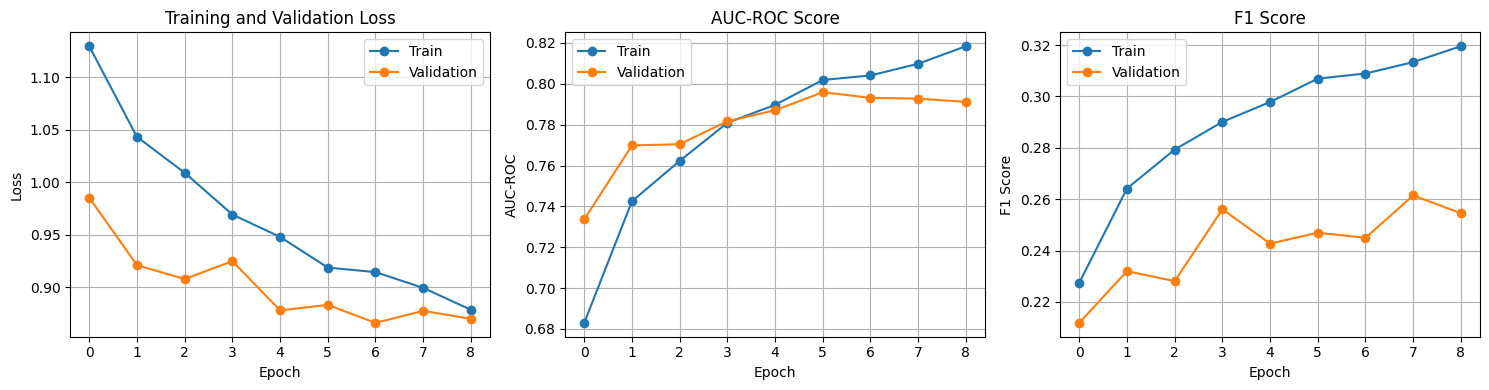

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Validation', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_auc'], label='Train', marker='o')
axes[1].plot(history['val_auc'], label='Validation', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC Score')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['train_f1'], label='Train', marker='o')
axes[2].plot(history['val_f1'], label='Validation', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [49]:
# torch.serialization.add_safe_globals([np.dtypes.Float64DType])
checkpoint = torch.load('./efficient_net-b1_model_v2.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with validation AUC: {checkpoint['val_auc']:.4f}")

test_metrics = validate_epoch(model, val_loader, criterion, device)
print_metrics(test_metrics, "FINAL TEST SET", config.DISEASES)

Loaded best model from epoch 6 with validation AUC: 0.7959


Validation: 100%|██████████| 400/400 [03:46<00:00,  1.77it/s, loss=0.439]



FINAL TEST SET RESULTS
Average Loss: 0.8830
Macro AUC-ROC: 0.7959
Macro F1 Score: 0.2469

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.7412   0.3576   0.7309
Cardiomegaly           0.8678   0.1958   0.7076
Effusion               0.8178   0.5004   0.7183
Infiltration           0.6202   0.4141   0.5702
Mass                   0.7996   0.2455   0.6807
Nodule                 0.7232   0.2040   0.6812
Pneumonia              0.6894   0.0687   0.5953
Pneumothorax           0.8511   0.3463   0.6492
Consolidation          0.7320   0.2015   0.5269
Edema                  0.8390   0.1607   0.6746
Emphysema              0.9242   0.2768   0.7995
Fibrosis               0.8129   0.0957   0.7823
Pleural_Thickening     0.7817   0.1626   0.6293
Hernia                 0.9420   0.2273   0.9841



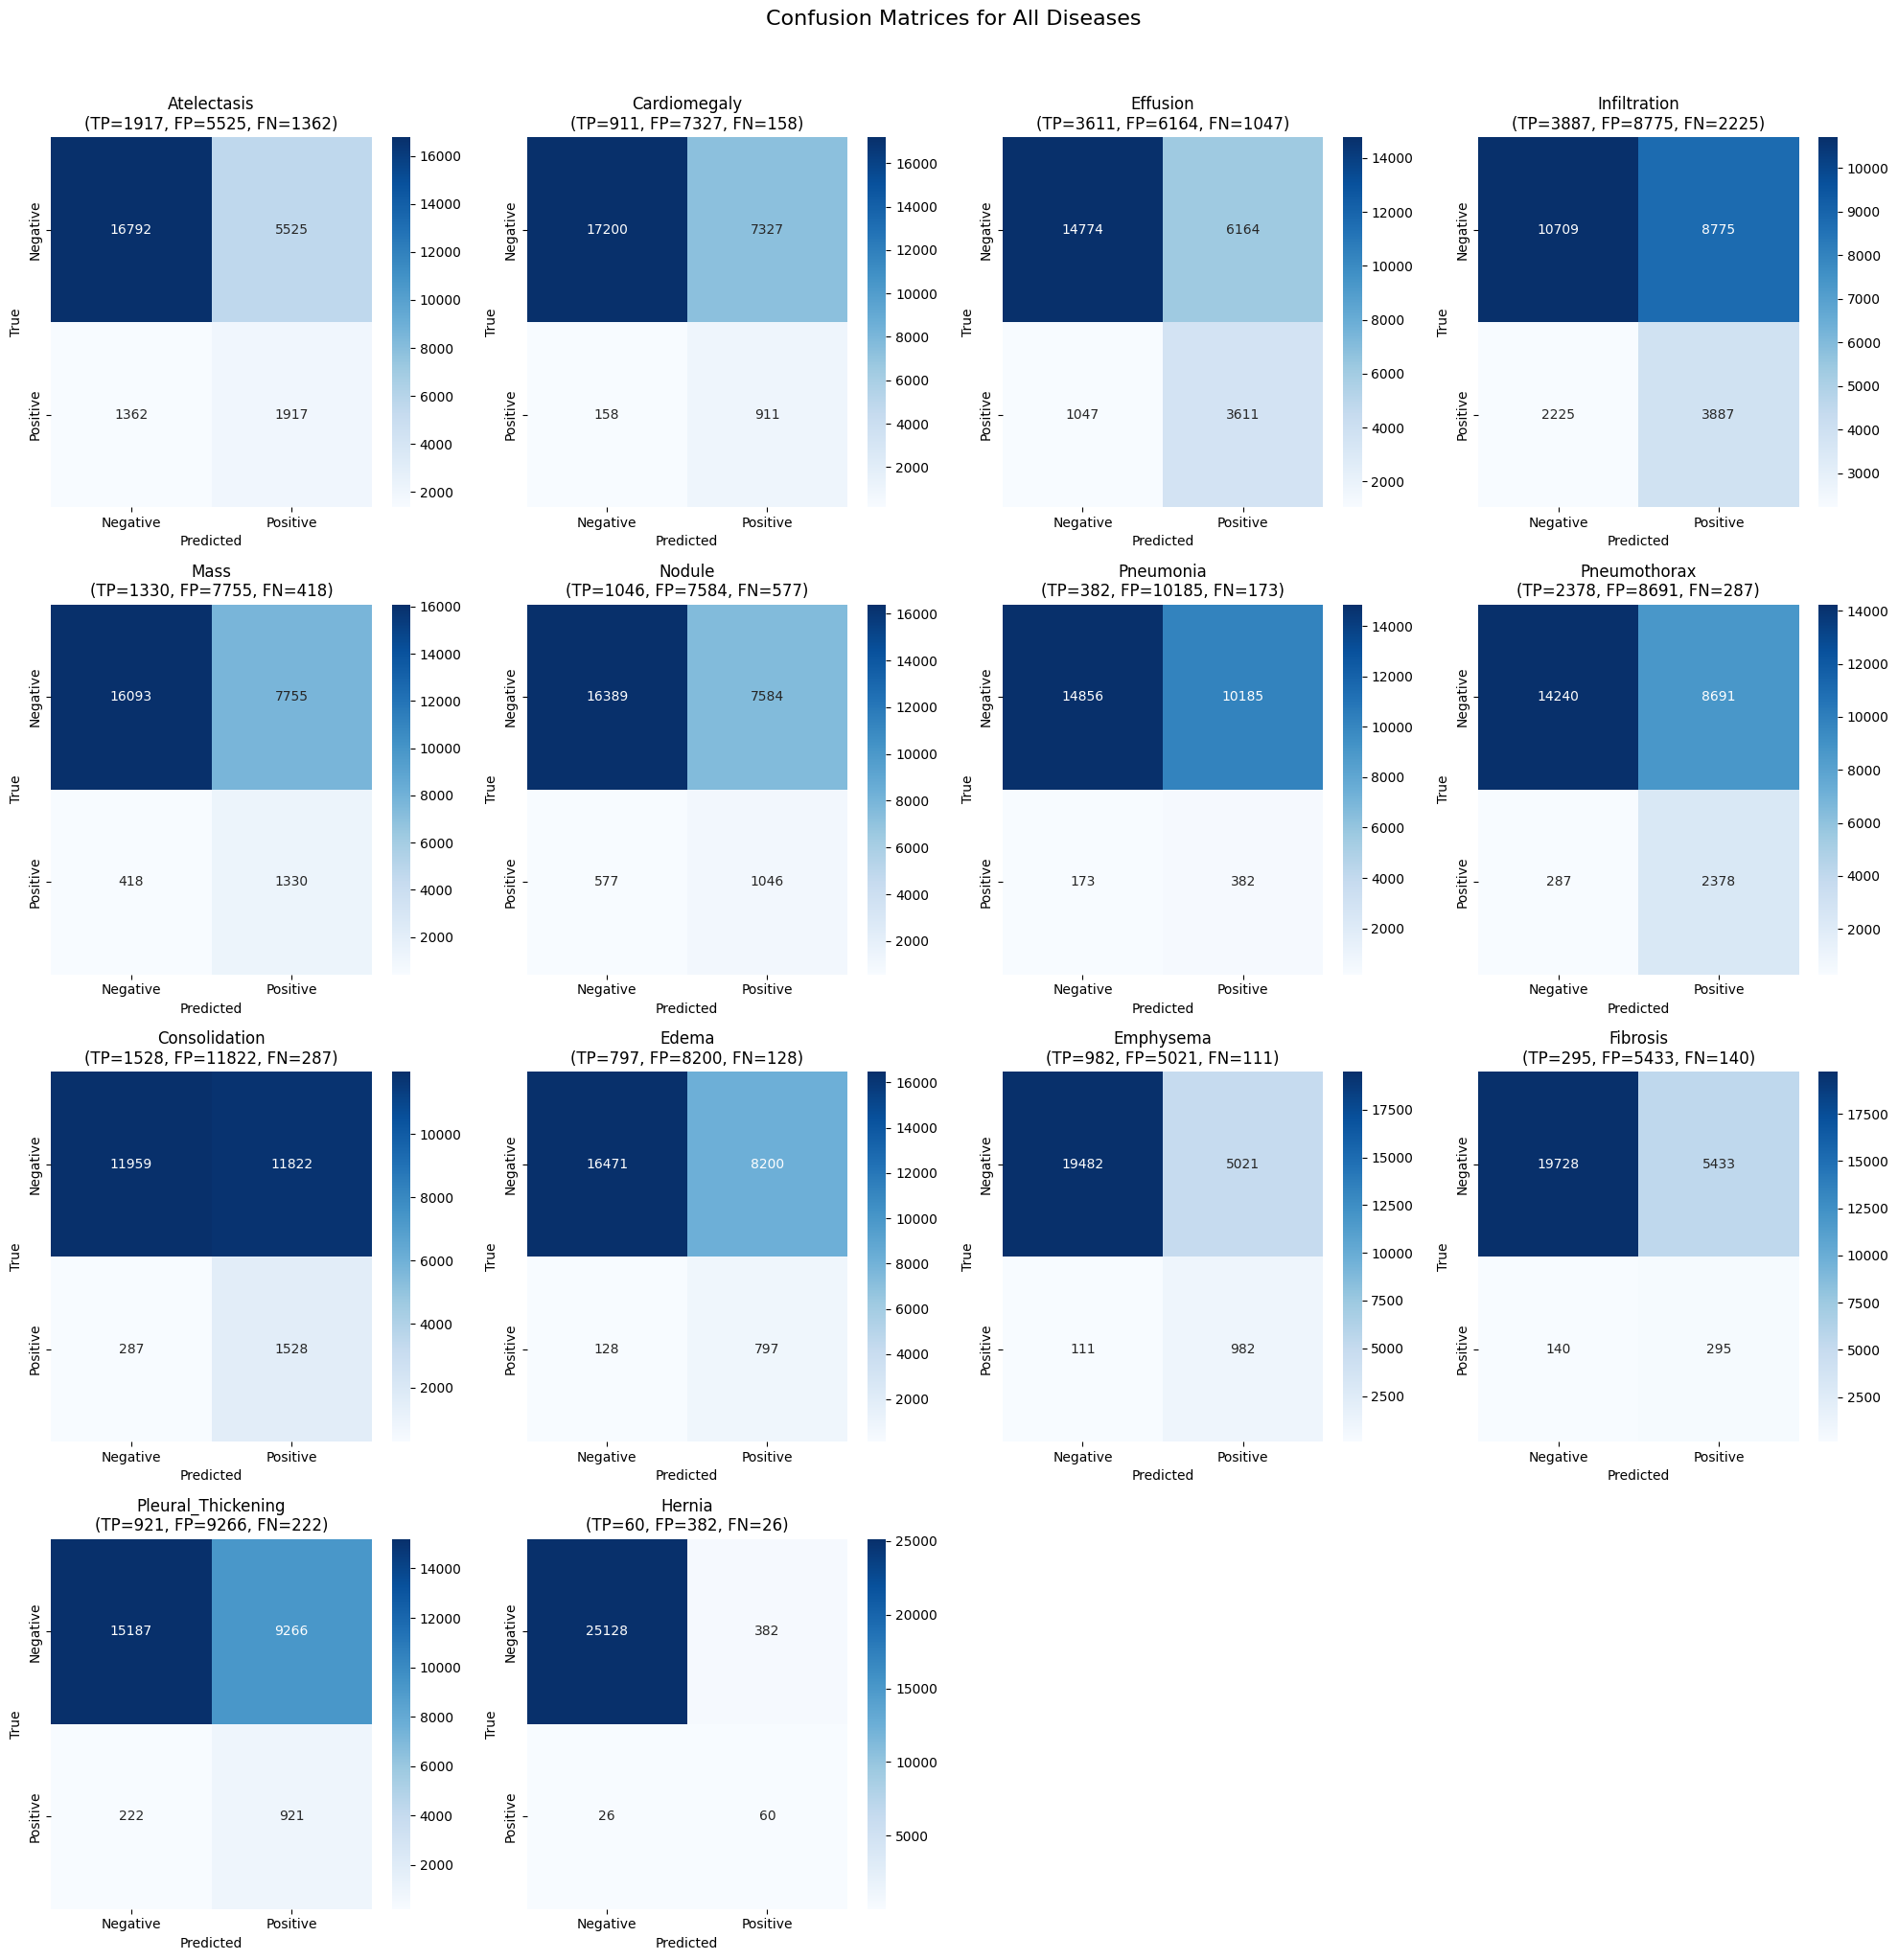

In [50]:
def plot_confusion_matrices(y_true, y_pred, diseases, save_path=None):
    n_diseases = len(diseases)
    n_cols = 4
    n_rows = (n_diseases + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axes = axes.flatten()
    
    for i, disease in enumerate(diseases):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                   xticklabels=['Negative', 'Positive'],
                   yticklabels=['Negative', 'Positive'])
        axes[i].set_title(f'{disease}\n(TP={cm[1,1]}, FP={cm[0,1]}, FN={cm[1,0]})')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Confusion Matrices for All Diseases', fontsize=16, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(test_metrics['y_true'], test_metrics['y_pred'], config.DISEASES, 'confusion_matrices.png')

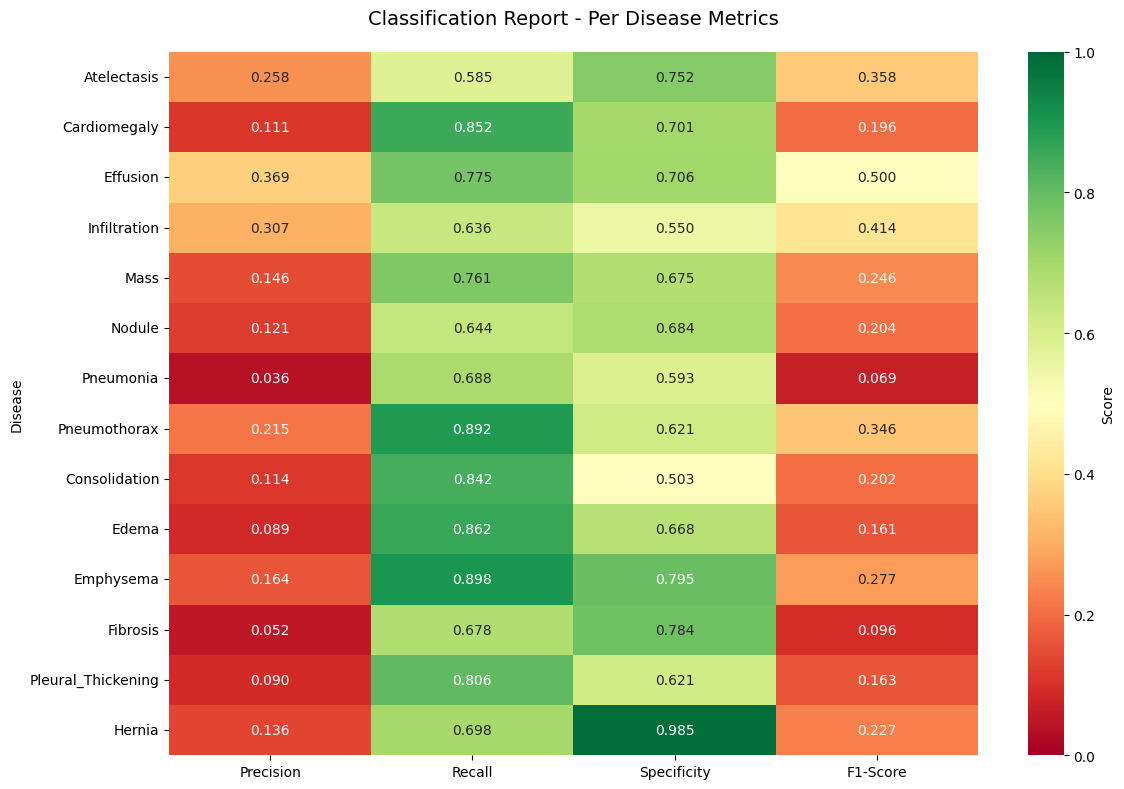


Classification Report:
           Disease  Precision   Recall  Specificity  F1-Score
       Atelectasis   0.257592 0.584629     0.752431  0.357616
      Cardiomegaly   0.110585 0.852198     0.701268  0.195767
          Effusion   0.369412 0.775225     0.705607  0.500381
      Infiltration   0.306982 0.635962     0.549630  0.414083
              Mass   0.146395 0.760870     0.674815  0.245546
            Nodule   0.121205 0.644486     0.683644  0.204038
         Pneumonia   0.036150 0.688288     0.593267  0.068693
      Pneumothorax   0.214834 0.892308     0.620993  0.346294
     Consolidation   0.114457 0.841873     0.502880  0.201517
             Edema   0.088585 0.861622     0.667626  0.160653
         Emphysema   0.163585 0.898445     0.795086  0.276776
          Fibrosis   0.051501 0.678161     0.784071  0.095733
Pleural_Thickening   0.090409 0.805774     0.621069  0.162577
            Hernia   0.135747 0.697674     0.985025  0.227273


In [51]:
def plot_classification_report(y_true, y_pred, diseases):
    report_data = []
    for i, disease in enumerate(diseases):
        tn, fp, fn, tp = confusion_matrix(y_true[:, i], y_pred[:, i]).ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        report_data.append({
            'Disease': disease,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'F1-Score': f1
        })
    
    report_df = pd.DataFrame(report_data)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(report_df.set_index('Disease'), annot=True, fmt='.3f', cmap='RdYlGn', 
                cbar_kws={'label': 'Score'}, ax=ax, vmin=0, vmax=1)
    ax.set_title('Classification Report - Per Disease Metrics', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    return report_df

report_df = plot_classification_report(test_metrics['y_true'], test_metrics['y_pred'], config.DISEASES)
print("\nClassification Report:")
print(report_df.to_string(index=False))

In [52]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class GradCAMVisualizer:
    
    def __init__(self, model, target_layers, device):
        self.model = model
        self.device = device
        self.cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    
    def visualize(self, image_tensor, metadata, disease_idx, threshold=0.5):
        self.model.eval()
        
        with torch.no_grad():
            logits = self.model(image_tensor.unsqueeze(0).to(self.device))
            probs = torch.sigmoid(logits).cpu().numpy()[0]
        
        disease_name = config.DISEASES[disease_idx]
        is_predicted = probs[disease_idx] >= threshold

        img_np = image_tensor.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        targets = [ClassifierOutputTarget(disease_idx)]
        
        grayscale_cam = self.cam(input_tensor=image_tensor.unsqueeze(0).to(self.device),targets=targets)[0]
        
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(img_np)
        axes[0].set_title(f'Original X-ray\n{metadata["img_name"]}')
        axes[0].axis('off')
        
        axes[1].imshow(img_np)
        axes[1].imshow(grayscale_cam, cmap='jet', alpha=0.5)
        axes[1].set_title(f'Grad-CAM++: {disease_name}\nPrediction: {is_predicted} (Prob: {probs[disease_idx]:.3f})')
        axes[1].axis('off')
        
        axes[2].imshow(visualization)
        axes[2].set_title(f'Overlay Visualization')
        axes[2].axis('off')
        
        plt.suptitle(f'Patient: {metadata["patient_id"]}, Age: {metadata["age"]}, Gender: {metadata["gender"]}')
        plt.tight_layout()
        plt.show()
        
        return visualization, probs[disease_idx]


GRAD-CAM++ VISUALIZATION EXAMPLES

--- Example 1: 00000003_000.png ---
Ground truth: ['Hernia']


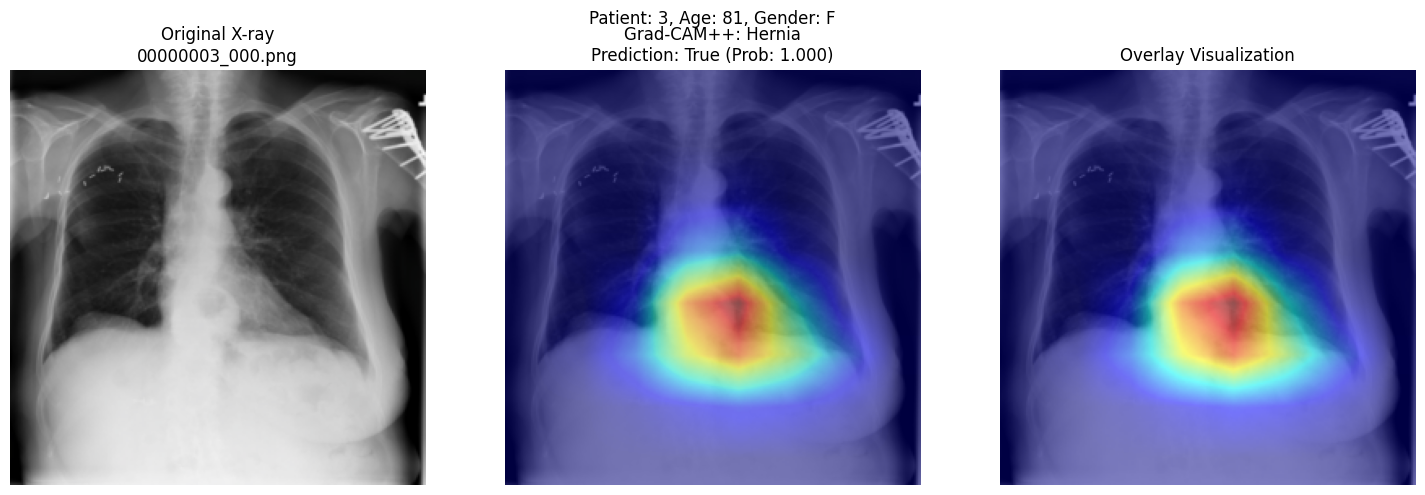


--- Example 2: 00000003_001.png ---
Ground truth: ['Hernia']


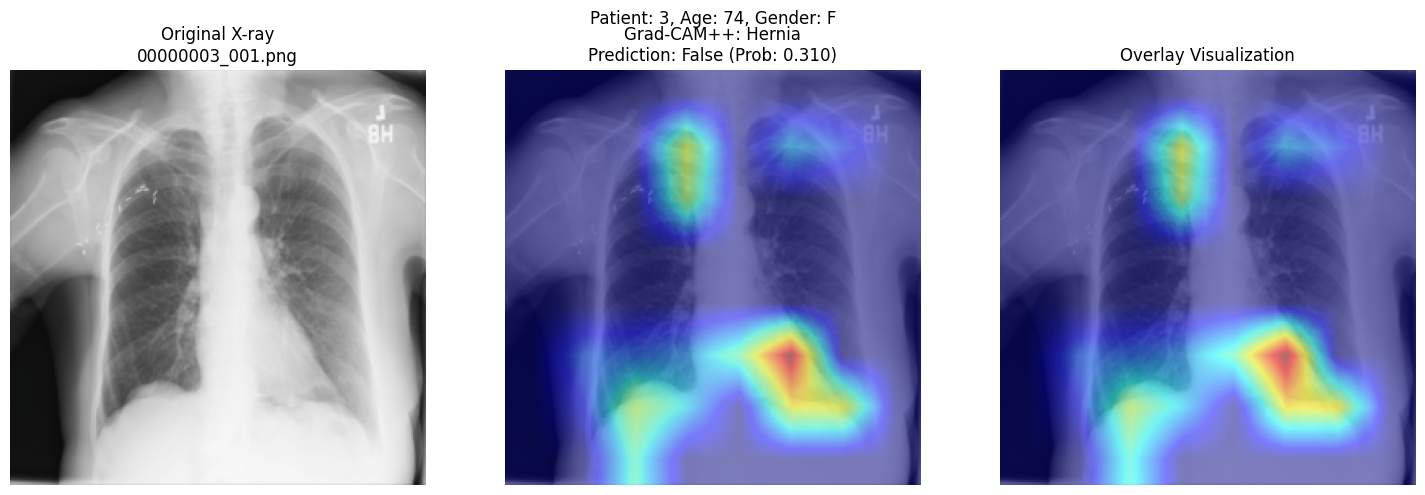


--- Example 3: 00000003_002.png ---
Ground truth: ['Hernia']


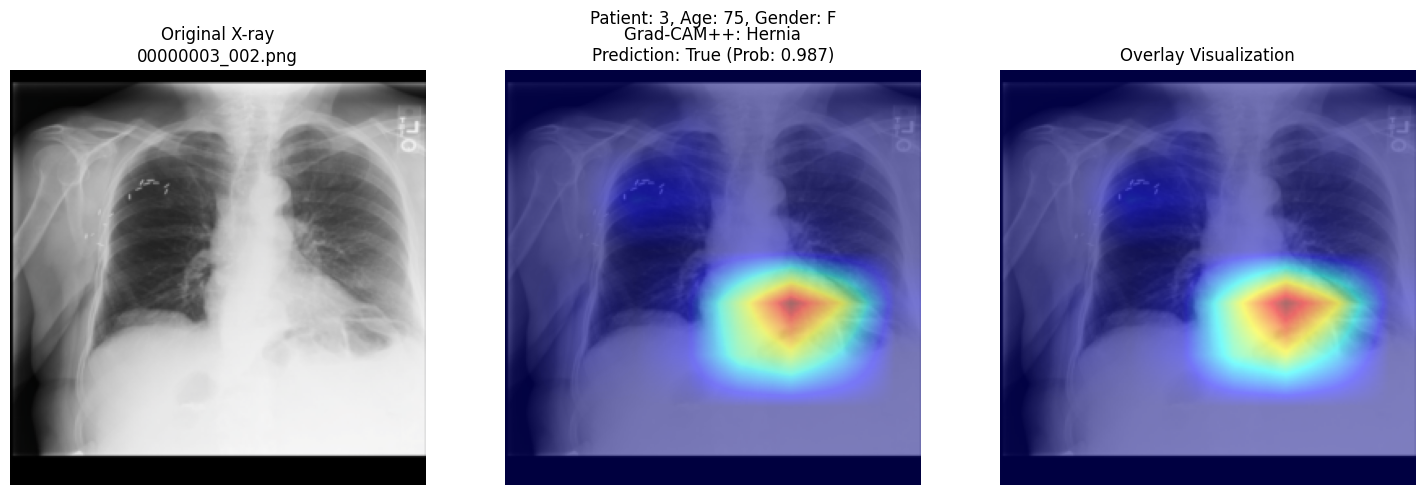


--- Example 4: 00000003_003.png ---
Ground truth: ['Infiltration', 'Hernia']


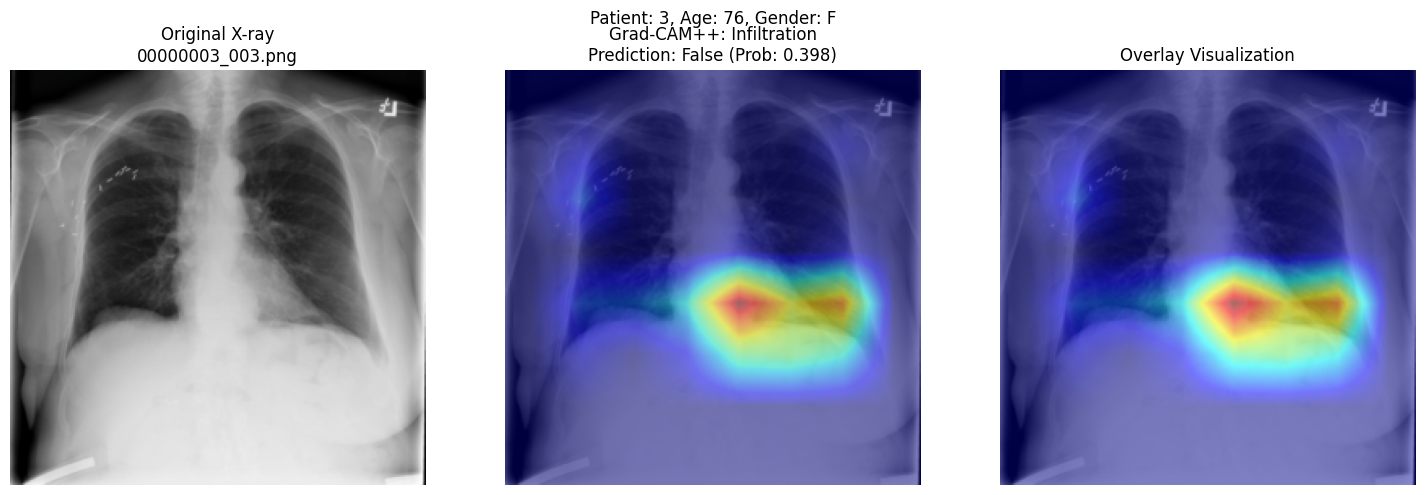


--- Example 5: 00000003_004.png ---
Ground truth: ['Hernia']


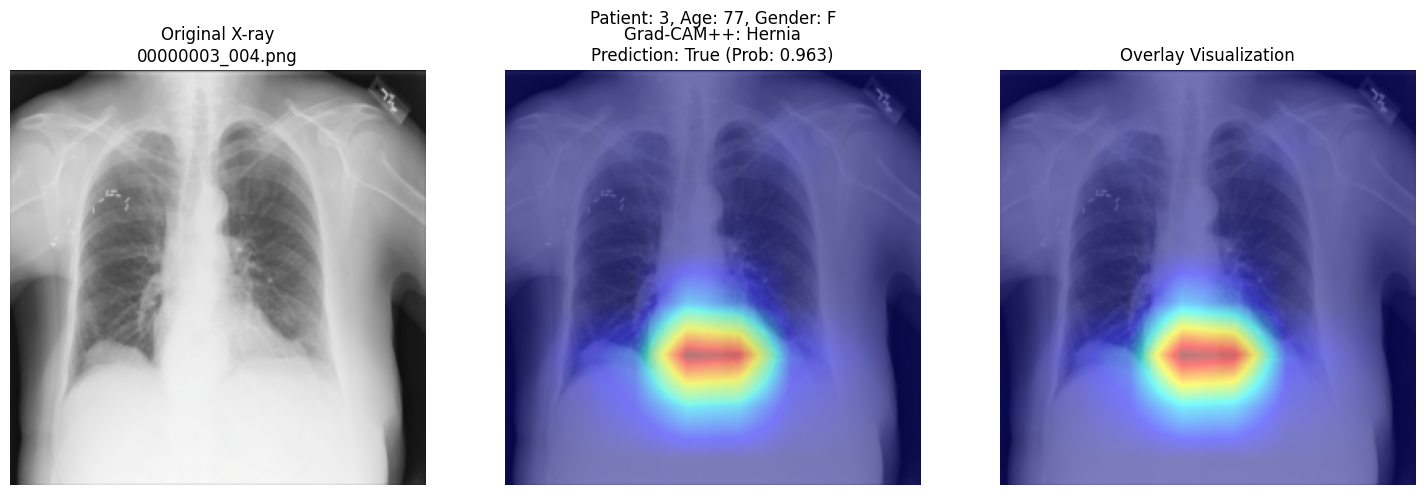


--- Example 6: 00000003_005.png ---
Ground truth: ['Hernia']


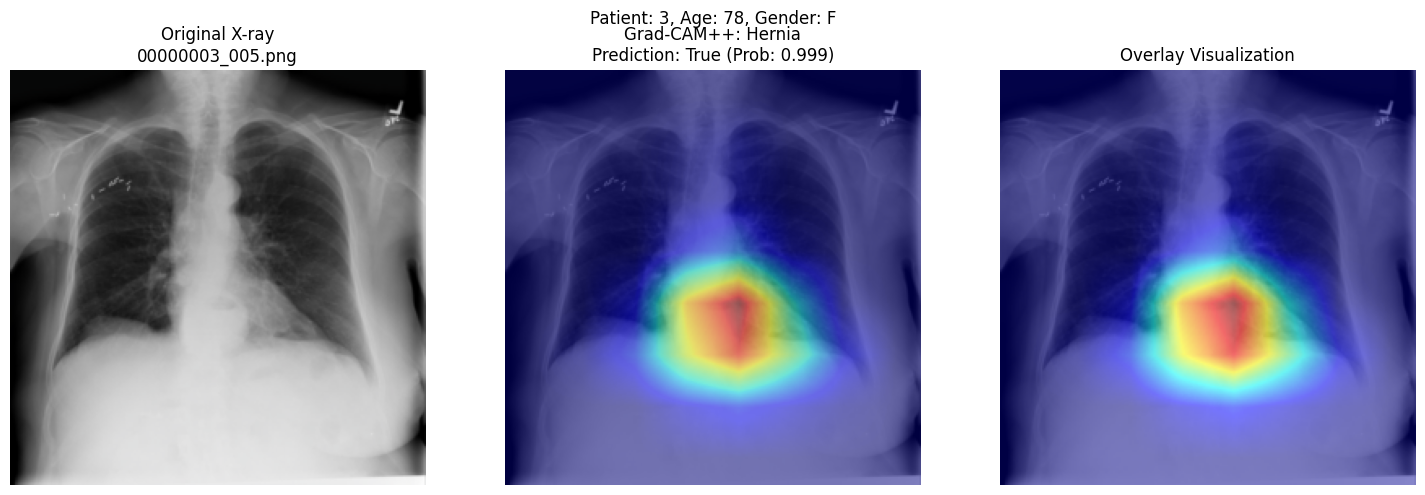


--- Example 7: 00000003_006.png ---
Ground truth: ['Hernia']


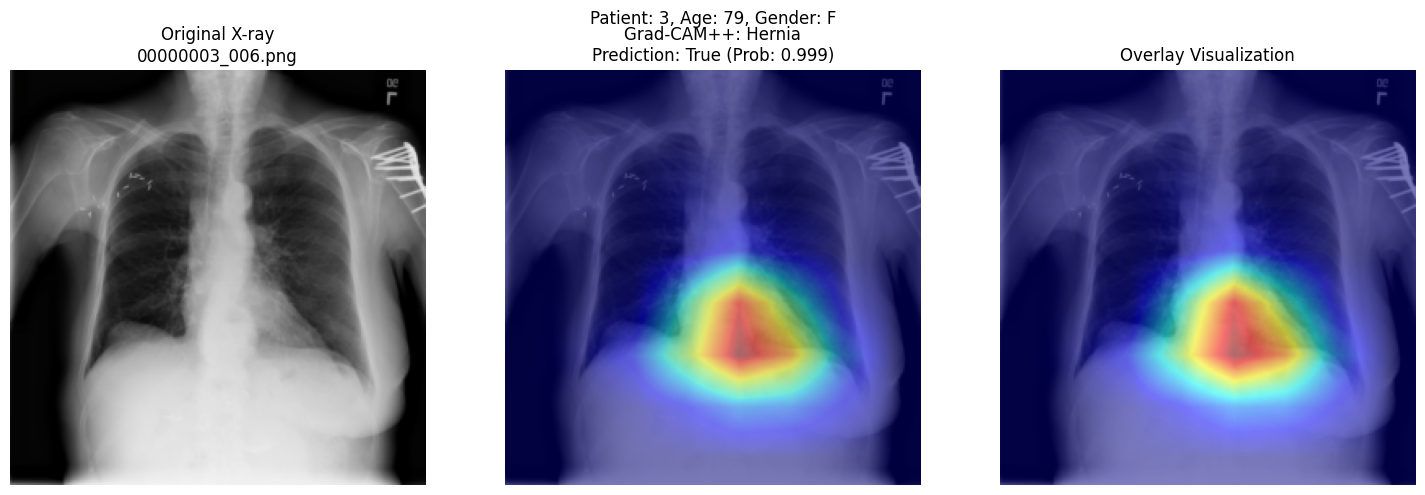


--- Example 8: 00000003_007.png ---
Ground truth: ['Hernia']


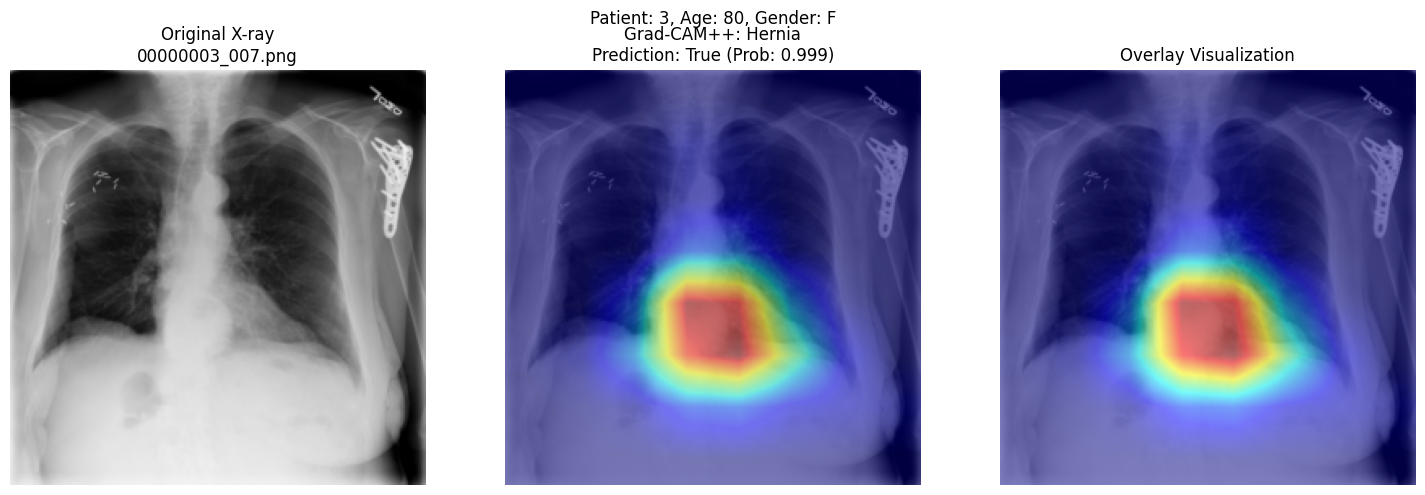


--- Example 10: 00000013_001.png ---
Ground truth: ['Pneumothorax', 'Emphysema']


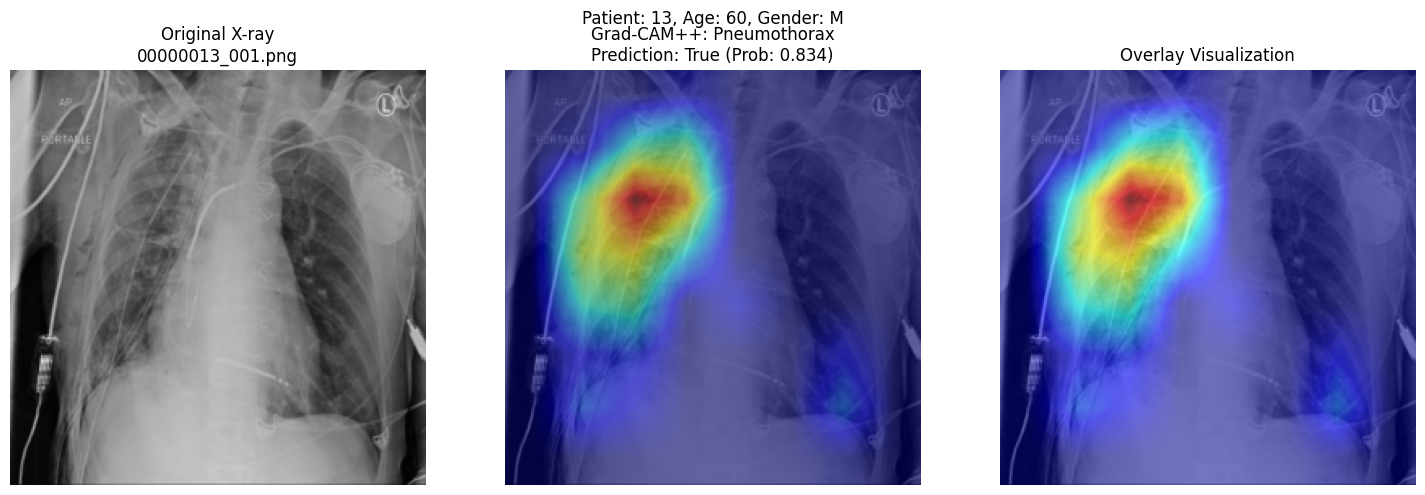


--- Example 11: 00000013_002.png ---
Ground truth: ['Pneumothorax', 'Emphysema']


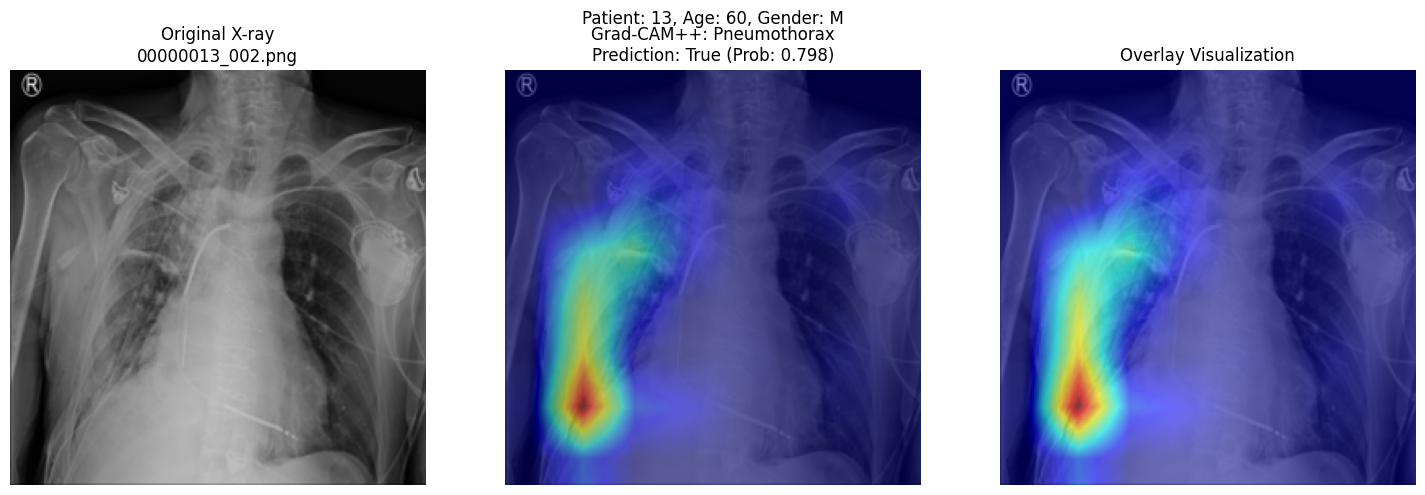


--- Example 12: 00000013_003.png ---
Ground truth: ['Pleural_Thickening']


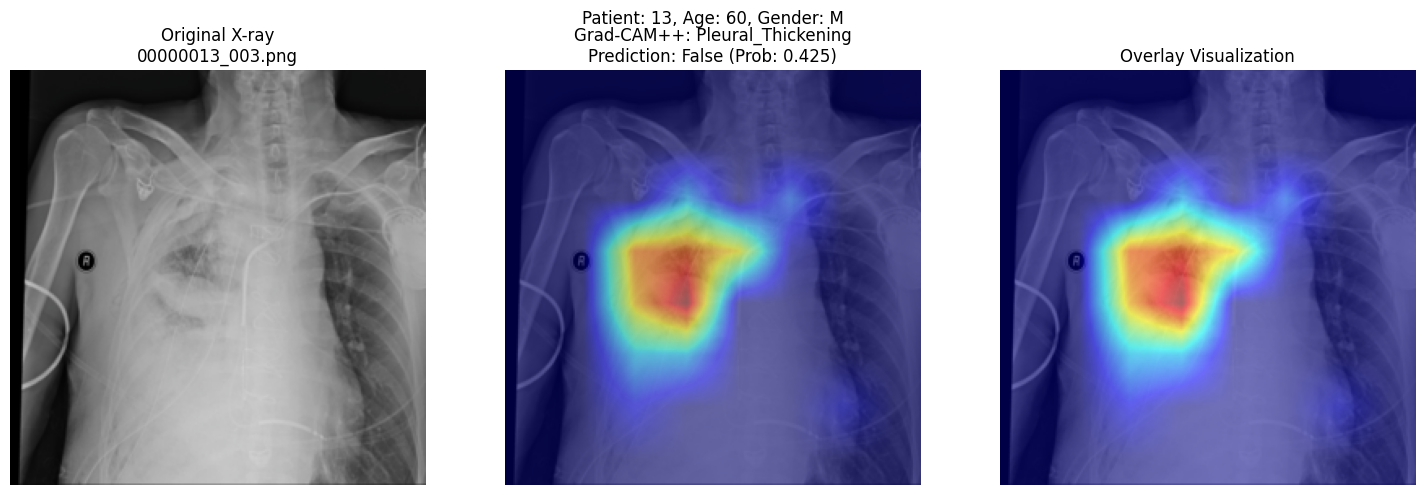


--- Example 13: 00000013_004.png ---
Ground truth: ['Effusion', 'Infiltration', 'Pneumothorax', 'Emphysema']


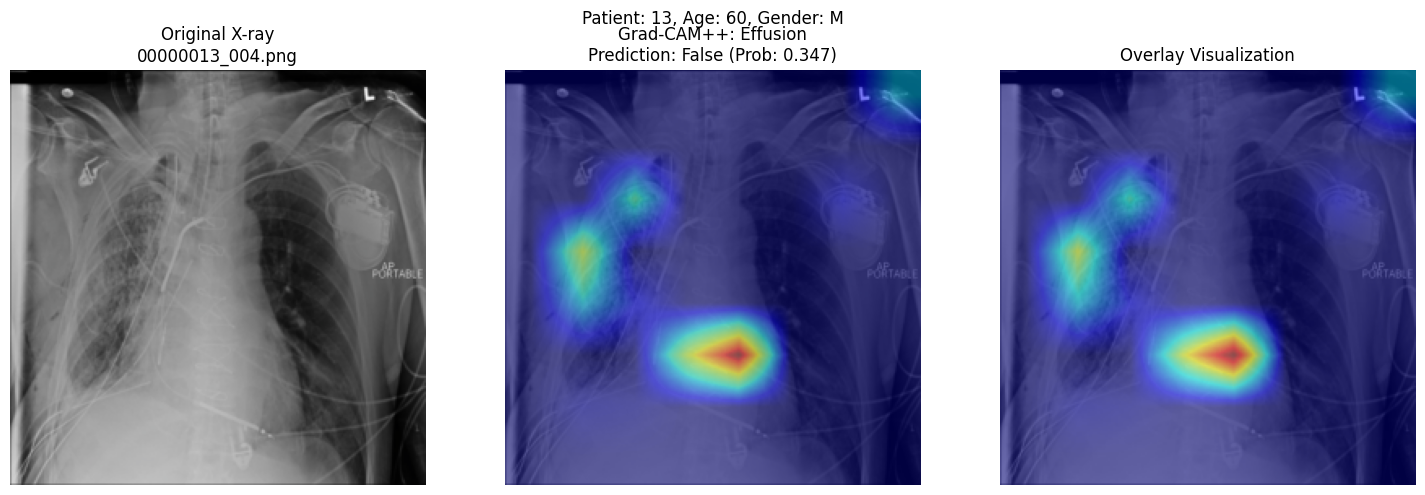


--- Example 14: 00000013_005.png ---
Ground truth: ['Infiltration', 'Pneumothorax', 'Emphysema', 'Pleural_Thickening']


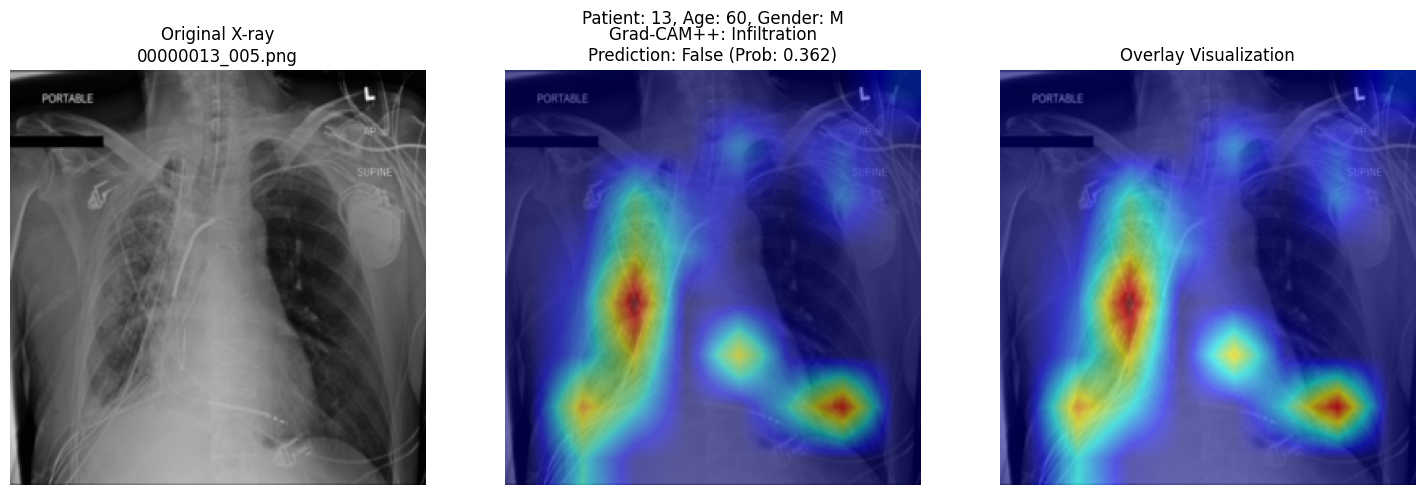


--- Example 15: 00000013_006.png ---
Ground truth: ['Effusion', 'Infiltration']


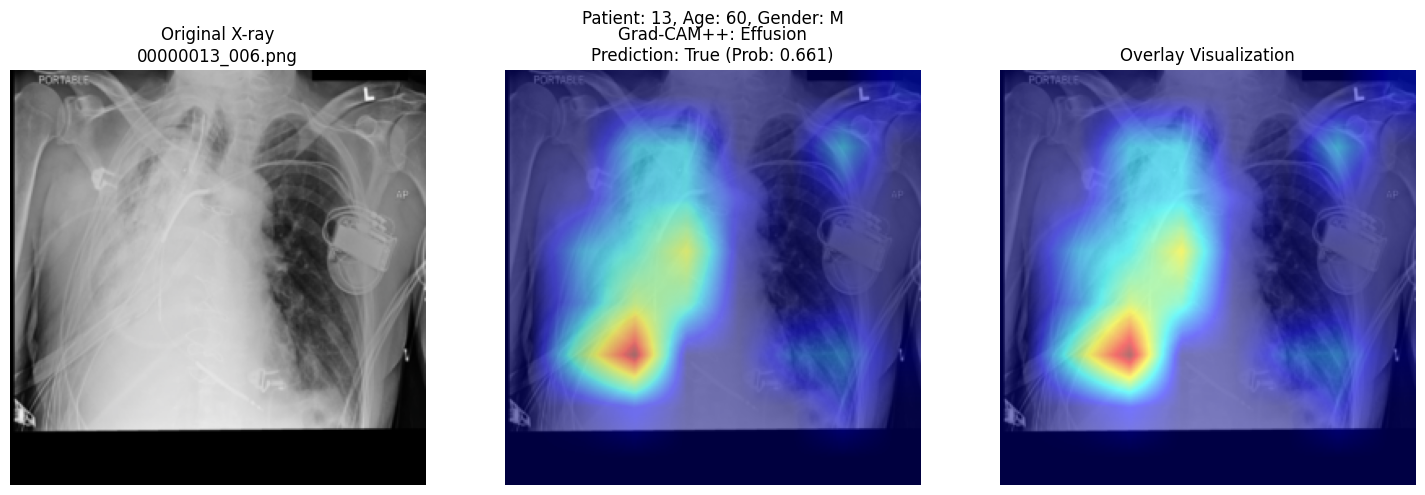

In [53]:
target_layers = [model.backbone.features[-1]]

visualizer = GradCAMVisualizer(model, target_layers, device)

print("\n" + "="*60)
print("GRAD-CAM++ VISUALIZATION EXAMPLES")
print("="*60)

num_examples = 15
diseases_to_visualize = [0, 1, 3, 6, 7]  # Atelectasis, Cardiomegaly, Infiltration, Pneumonia, Pneumothorax

for idx in range(min(num_examples, len(val_dataset))):
    image, labels, metadata = val_dataset[idx]
    
    present_diseases = [i for i, label in enumerate(labels) if label == 1]
    
    if present_diseases:
        disease_idx = present_diseases[0]
        print(f"\n--- Example {idx+1}: {metadata['img_name']} ---")
        print(f"Ground truth: {[config.DISEASES[i] for i in present_diseases]}")
        
        try:
            vis, prob = visualizer.visualize(image, metadata, disease_idx)
        except Exception as e:
            print(f"Could not generate Grad-CAM++: {e}")

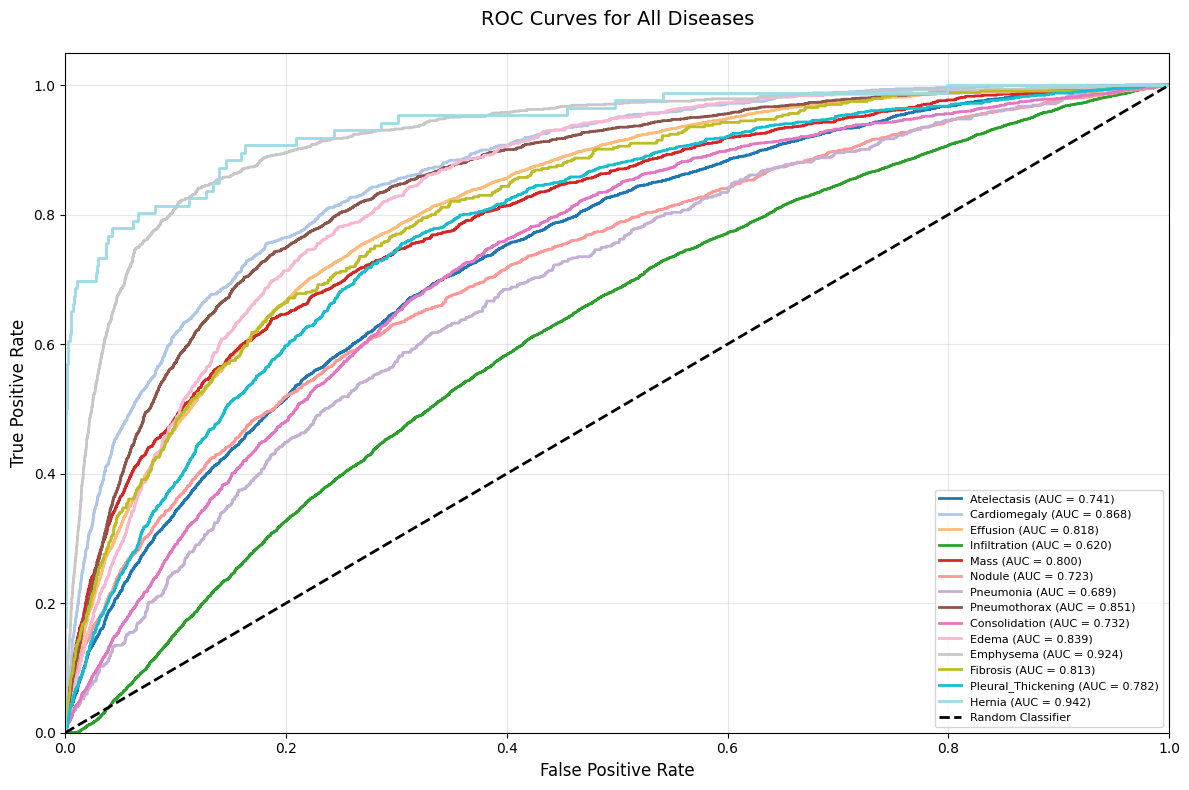

In [54]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(y_true, y_proba, diseases):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(diseases)))
    
    for i, (disease, color) in enumerate(zip(diseases, colors)):
        if len(np.unique(y_true[:, i])) > 1:
            fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2,
                   label=f'{disease} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves for All Diseases', fontsize=14, pad=20)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_roc_curves(test_metrics['y_true'], test_metrics['y_proba'], config.DISEASES)

In [55]:
def generate_summary_report(metrics, diseases, history, save_path='results_summary.txt'):
    
    with open(save_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("NIH CHEST X-RAY MULTI-LABEL CLASSIFICATION RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Model: EfficientNet-B1\n")
        f.write(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}\n")
        f.write(f"Batch Size: {config.BATCH_SIZE}\n")
        f.write(f"Learning Rate: {config.LEARNING_RATE}\n\n")
        
        f.write("FINAL METRICS\n")
        f.write("-"*40 + "\n")
        f.write(f"Macro AUC-ROC: {metrics['macro_auc']:.4f}\n")
        f.write(f"Macro F1 Score: {metrics['macro_f1']:.4f}\n")
        f.write(f"Average Loss: {metrics['avg_loss']:.4f}\n\n")
        
        f.write("PER-CLASS METRICS\n")
        f.write("-"*40 + "\n")
        f.write(f"{'Disease':<22} {'AUC':<8} {'F1':<8} {'Accuracy':<8}\n")
        f.write("-"*50 + "\n")
        
        for i, disease in enumerate(diseases):
            f.write(f"{disease:<22} {metrics['auc_per_class'][i]:.4f}   "
                   f"{metrics['f1_per_class'][i]:.4f}   "
                   f"{metrics['accuracy_per_class'][i]:.4f}\n")
        
        f.write("\nTRAINING HISTORY\n")
        f.write("-"*40 + "\n")
        f.write(f"Best Validation AUC: {max(history['val_auc']):.4f}\n")
        f.write(f"Best Validation F1: {max(history['val_f1']):.4f}\n")
        f.write(f"Final Training AUC: {history['train_auc'][-1]:.4f}\n")
        f.write(f"Final Validation AUC: {history['val_auc'][-1]:.4f}\n")
        
    print(f"Summary report saved to {save_path}")

generate_summary_report(test_metrics, config.DISEASES, history)

Summary report saved to results_summary.txt


In [56]:
def predict_single_image(model, image_path, transform, device):
    model.eval()
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    threshold = 0.5
    predictions = [(config.DISEASES[i], probs[i]) 
                   for i in range(len(config.DISEASES)) 
                   if probs[i] >= threshold]
    
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    return predictions, probs

In [57]:
def display_prediction(image_path, predictions, probs, save_path=None):
    image = Image.open(image_path).convert('RGB')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.imshow(image, cmap='gray')
    ax1.set_title('Chest X-ray Image')
    ax1.axis('off')
    
    if predictions:
        diseases, scores = zip(*predictions)
        bars = ax2.barh(diseases, scores, color='skyblue')
        ax2.set_xlim(0, 1)
        ax2.set_xlabel('Probability')
        ax2.set_title('Disease Predictions')
        
        for bar, score in zip(bars, scores):
            if score >= 0.7:
                bar.set_color('green')
            elif score >= 0.5:
                bar.set_color('orange')
            else:
                bar.set_color('red')
    else:
        ax2.text(0.5, 0.5, 'No diseases detected\n(All probabilities < 0.5)',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Predictions')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()